最佳参数: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 20}

验证集准确率: 0.8100558659217877

分类报告:
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       105
           1       0.84      0.66      0.74        74

    accuracy                           0.81       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


混淆矩阵:
[[96  9]
 [25 49]]

特征重要性:
                       Feature  Importance
4             onehot__Title_Mr    0.445219
14             remainder__Fare    0.252665
11           remainder__Pclass    0.140735
6           onehot__Title_Rare    0.076662
15       remainder__FamilySize    0.042819
2           onehot__Embarked_S    0.017861
1           onehot__Embarked_Q    0.009388
10  onehot__AgeBand_YoungAdult    0.007627
8       onehot__AgeBand_Senior    0.004898
12            remainder__SibSp    0.002126
13            

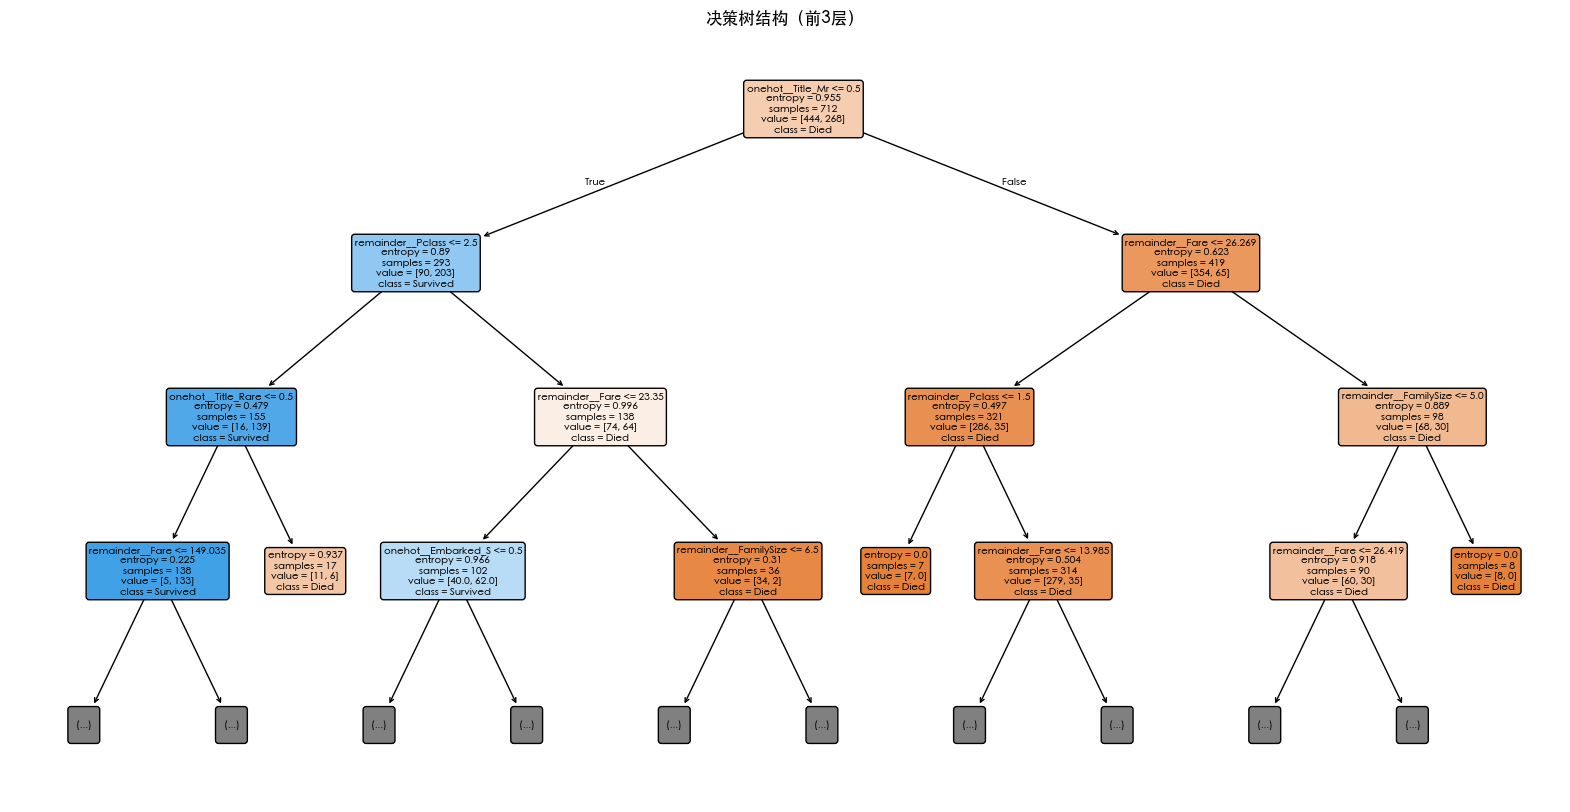


测试集预测结果已保存到 submission.csv


In [5]:
# -*-coding: utf-8 -*-
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 配置 matplotlib 使用字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 数据预处理函数
def preprocess_data(data, is_train=True):
    # 1. 删除无用列
    drop_cols = ["Ticket", "Cabin"]
    if is_train:
        drop_cols.append("PassengerId")
    data = data.drop(drop_cols, axis=1)
    
    # 2. 处理缺失值
    data["Age"] = data["Age"].fillna(data["Age"].median())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
    data["Fare"] = data["Fare"].fillna(data["Fare"].median())
    
    # 3. 特征工程
    # FamilySize & IsAlone
    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
    
    # Title处理
    data["Title"] = data["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_mapping = {
        'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
        'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
        'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare',
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
    }
    data["Title"] = data["Title"].replace(title_mapping)
    
    # AgeBand分段（直接覆盖Age列，无需保留原始Age）
    data["AgeBand"] = pd.cut(data["Age"], bins=[0, 12, 18, 30, 50, 100], 
                            labels=['Child','Teenager','YoungAdult','Adult','Senior'])
    data = data.drop(["Name","Age"], axis=1)
    
    return data


def main():
    # 1. 加载数据
    train_data = pd.read_csv("train.csv")
    test_data = pd.read_csv("test.csv")
    
    # 2. 数据预处理
    train_data = preprocess_data(train_data, is_train=True)
    test_data = preprocess_data(test_data, is_train=False)
    
    # 3. 类别型变量编码
    preprocessor = ColumnTransformer(
        transformers=[
            ("onehot", OneHotEncoder(drop="first"), ["Sex", "Embarked", "Title", "AgeBand"])
        ],
        remainder="passthrough"
    )
    
    # 分割特征与标签
    X_train = train_data.drop("Survived", axis=1)
    y_train = train_data["Survived"]
    X_test = test_data.drop("PassengerId", axis=1)  # 测试数据中因为保留了 PassengerId
    
    # 应用预处理
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)
    
    # 4. 数据分割
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train_processed, y_train, test_size=0.2, random_state=42
    )
    
    # 5. 模型训练与调优
    clf = DecisionTreeClassifier(random_state=42)
    
    # 定义参数网格
    param_grid = {
        "max_depth": [3, 5, 7, 9, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8],
        "criterion": ["gini", "entropy"],
        "class_weight": [None, "balanced"]
    }
    
    # 网格搜索
    grid_search = GridSearchCV(clf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_split, y_train_split)
    
    # 获取最优模型
    best_clf = grid_search.best_estimator_
    print("最佳参数:", grid_search.best_params_)
    
    # 6. 模型评估
    y_pred = best_clf.predict(X_val)
    print("\n验证集准确率:", accuracy_score(y_val, y_pred))
    print("\n分类报告:")
    print(classification_report(y_val, y_pred))
    print("\n混淆矩阵:")
    print(confusion_matrix(y_val, y_pred))
    
    # 7. 特征重要性分析
    feature_names = preprocessor.get_feature_names_out()
    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_clf.feature_importances_
    }).sort_values("Importance", ascending=False)
    
    print("\n特征重要性:")
    print(feature_importance)
    
    # 8. 可视化决策树（可选）
    plt.figure(figsize=(20, 10))
    plot_tree(
        best_clf,
        feature_names=feature_names,
        class_names=["Died", "Survived"],
        filled=True,
        rounded=True,
        max_depth=3  # 限制深度以便查看
    )
    plt.title("决策树结构（前3层）")
    plt.show()
    
    # 9. 测试集预测
    test_pred = best_clf.predict(X_test_processed)
    # 创建提交文件
    submission = pd.DataFrame({
        "PassengerId": test_data["PassengerId"],
        "Survived": test_pred
    })
    #submission.to_csv("submission.csv", index=False)
    #print("\n测试集预测结果已保存到 submission.csv")


if __name__ == "__main__":
    main()